# Project Stochastic Simulation SRN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from simulation_functions import explicit_tau_leaping, MC_specificSampleSize, SSA_alg, implicit_tau_leaping, iterative_MC

## Section 3.2


In [2]:
nu = np.array([[-1, -1, 1, 0],
               [1, 1, -1, 0],
               [0, 1, -1, 1]])  # stochiometric vectors


def aCalc(x, c):
    a1 = c[0] * (x[0] * x[1]) * (x[0] >= 1 and x[1] >= 1)
    a2 = c[1] * (x[2]) * (x[2] >= 1)
    a3 = c[2] * (x[2]) * (x[2] >= 1)
    return np.array([a1, a2, a3])

### 3.2.1  - more exact equations for each single species in the report - in the report

Here are the functions to compute the drift vector f(x) and the diffusion matrix G(x) for the CLE.

In [ ]:
def simple_cle_drift(x, c):
    a = aCalc(x, c)

    f1 = -a[0] + a[1]
    f2 = -a[0] + a[1] + a[2]
    f3 = a[0] - a[1] - a[2]
    f4 = a[2]

    return np.array([f1, f2, f3, f4])


def cle_drift(x, c, nu):
    """Return the drift vector f(x) = sum_j nu_j * a_j(x). - optimized with matrix multiplication
    Returns a numpy array of length 4.
    """
    a = aCalc(x, c)
    return a @ nu


def simple_cle_diffusion(x, c):
    a = aCalc(x, c)

    sqrt_a1 = math.sqrt(a[0])
    sqrt_a2 = math.sqrt(a[1])
    sqrt_a3 = math.sqrt(a[2])

    H = np.zeros((4, 3))

   # --- Column 0: Reaction 1 Noise (affects S1, S2, S3) ---
    H[0, 0] = -1 * sqrt_a1  # S1
    H[1, 0] = -1 * sqrt_a1  # S2
    H[2, 0] =  1 * sqrt_a1  # S3

    # --- Column 1: Reaction 2 Noise (affects S1, S2, S3) ---
    H[0, 1] =  1 * sqrt_a2  # S1
    H[1, 1] =  1 * sqrt_a2  # S2
    H[2, 1] = -1 * sqrt_a2  # S3

    # --- Column 2: Reaction 3 Noise (affects S2, S3, S4) ---
    H[1, 2] =  1 * sqrt_a3  # S2
    H[2, 2] = -1 * sqrt_a3  # S3
    H[3, 2] =  1 * sqrt_a3  # S4

    return H

def cle_diffusion(x, c):
    """Return the diffusion matrix G(x) with shape (4,3).
    Column j is nu[j] * sqrt(a_j(x)).
    """
    a = aCalc(x, c)
    J = a.shape[0]
    H = np.zeros((nu.shape[1], J))

    for j in range(J):
        H[:, j] = nu[j] * math.sqrt(a[j])
    return H



### 3.2.2 Euler–Maruyama simulation of the CLE (tau = 0.2)

We simulate the CLE using the Euler–Maruyama scheme with time step tau = 0.2, starting from the same initial condition as before. The numerical update is:

    Y_{n+1} = Y_n + tau * f(Y_n) + sqrt(tau) * G(Y_n) Z_n

where Z_n ~ N(0, I) (one normal per reaction). We take the absolute value after each step to avoid negative molecule counts in the visualization.


In [ ]:
c = [0.0017, 1e-4, 0.1]  # rate constants
T = 50  # Total time
X0 = np.array([312, 125, 0, 0])

tau = 0.2
n_steps = int(np.ceil(T / tau))
times = np.linspace(0, T, n_steps + 1)

rng = np.random.default_rng(42)

x_s = np.zeros((n_steps + 1, X0.size))
x = X0.astype(float)
x_s[0, :] = x


for n in range(n_steps):
    #f = simple_cle_drift(x)
    f = cle_drift(x, c, nu)
    #G = simple_cle_diffusion(x)
    G = cle_diffusion(x, c)
    z = rng.normal(size=(G.shape[1],))
    x = x + tau * f + math.sqrt(tau) * (G @ z)
    x = np.abs(x) # note from the report - take absolute value to avoid negative molecule counts
    x_s[n + 1, :] = x


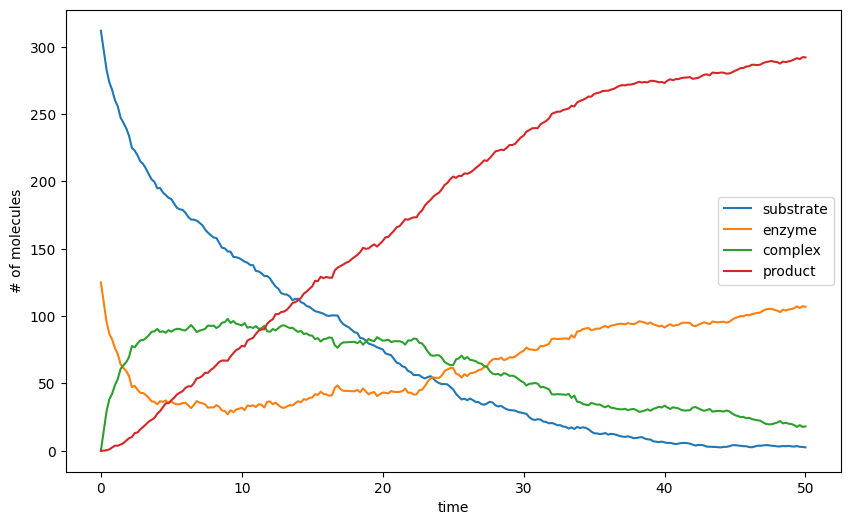

In [ ]:

plt.figure(figsize=(10, 6))
labels = ['substrate', 'enzyme', 'complex', 'product']
for i in range(X0.size):
    plt.plot(times, x_s[:, i], label=labels[i])
plt.xlabel("time")
plt.ylabel("# of molecules")
plt.legend()
plt.show()


### 3.2.3 Comparison with Tau-leaping and SSA (minimal)

We compare CLE, tau-leaping and SSA with a fixed computational budget.


In [ ]:
def cle_solver(c, X0, T, tau, nu, random_seed=42):
    number_steps = int(np.ceil(T / tau))
    t = np.linspace(0, T, number_steps + 1)

    Xs = np.zeros((len(t), 4))
    x = X0.astype(float)
    Xs[0] = x

    rng = np.random.default_rng(random_seed)

    for n in range(n_steps):

        f = cle_drift(x, c, nu)
        G = cle_diffusion(x, c)
        z = rng.normal(size=(G.shape[1],))
        x = x + tau * f + math.sqrt(tau) * (G @ z)
        x = np.abs(x) # note from the report - take absolute value to avoid negative molecule counts
        Xs[n+1] = x

    return t, Xs

In [ ]:
# Parameters for explicit tau leaping
c = [0.0017, 1e-4, 0.1] # rate constants
T = 50 # Total time
tau = 0.2
X0 = np.array([312, 125, 0, 0])

# Parameters for Monte Carlo
alpha = 0.05
tol = 0.2
Nb = 200
Nmax = 2000

muN, halfwidth, N = iterative_MC(cle_solver, [c, X0, T, tau, nu], Nb=200, Nmax=Nmax, alpha=alpha, tol=tol)
print("95% confidence interval for mu: [", muN-halfwidth,' , ',muN+halfwidth,']')
print(f'halfwidth is {halfwidth}')
print("Calculated by N = ", N, " iterations")

95% confidence interval for mu: [ 292.20070924495457  ,  292.2007092449549 ]
halfwidth is 1.5795440403209034e-13
Calculated by N =  200  iterations


In [ ]:
# Parameters for explicit tau leaping
c = [0.0017, 1e-4, 0.1] # rate constants
T = 50 # Total time
tau = 0.2
X0 = np.array([312, 125, 0, 0])

# Parameters for Monte Carlo
alpha = 0.05
tol = 0.1
Nb = 200
Nmax = 2000

ssa_muN, ssa_halfwidth, N = iterative_MC(SSA_alg, [c, X0, T, nu], Nb=Nb, Nmax=Nmax, alpha=alpha, tol=tol)
print("95% confidence interval for mu: [", ssa_muN-halfwidth,' , ',ssa_muN+halfwidth,']')
print(f'halfwidth is {halfwidth}')
print("Calculated by N = ", N, " iterations")

95% confidence interval for mu: [ 296.74310344827563  ,  296.743103448276 ]
halfwidth is 1.5795440403209034e-13
Calculated by N =  2000  iterations


 ## Compare with fixed computational cost

In [ ]:
c_rates = [0.0017, 1e-4, 0.1]
X0_init = np.array([312, 125, 0, 0])
T_end = 50
tau_step = 0.2
N_samples = 500 # Fixed computational cost (Sample size)

mean_tau_ex, halfwidth_tau_ex = MC_specificSampleSize(explicit_tau_leaping, [c_rates, X0_init, T_end, tau_step, nu], N_samples)
mean_tau_im, halfwidth_tau_im = MC_specificSampleSize(implicit_tau_leaping, [c_rates, X0_init, T_end, tau_step, nu], N_samples)
mean_cle, halfwidth_cle = MC_specificSampleSize(cle_solver, [c_rates, X0_init, T_end, tau_step, nu], N_samples)


print(f"SSA Mean:                    {ssa_muN}")
print(f"Explicit Tau-Leaping Mean:   {mean_tau_ex:.4f} (Error: {abs(mean_tau_ex - ssa_muN):.4f})")
print(f"Implicit Tau-Leaping Mean:   {mean_tau_im:.4f} (Error: {abs(mean_tau_im - ssa_muN):.4f})")
print(f"CLE Mean:                    {mean_cle:.4f}    (Error: {abs(mean_cle - ssa_muN):.4f})")

errors = {
    "Explicit Tau-Leaping": abs(mean_tau_ex - ssa_muN),
    "Implicit Tau-Leaping": abs(mean_tau_im - ssa_muN),
    "CLE": abs(mean_cle - ssa_muN)
}
print(f"Smallest Error Method: {min(errors, key=errors.get)} with Error: {min(errors.values()):.4f}")

SSA Reference Mean:          296.7354397801099
Explicit Tau-Leaping Mean:   296.4520 (Error: 0.2834)
Implicit Tau-Leaping Mean:   295.5760 (Error: 1.1594)
CLE Mean:                    292.2007    (Error: 4.5347)
Smallest Error Method: Explicit Tau-Leaping with Error: 0.2834
